# FreshHarvest Logistics — Transfer Learning with ResNet50

**Goal.** Training a CNN from scratch is compute-heavy. Here we use **transfer learning** — start from a **ResNet50** already trained on ImageNet (1.2M images) and adapt it to the FRUIT-16K fresh/spoiled task. The pretrained convolutional features (edges, textures, colour patterns) transfer directly to fruit images, so we reach strong accuracy in **far fewer epochs**, cutting training time and cost.

**Dataset.** Same `FRUIT-16K` as before — 16,000 images, 224×224 RGB, 16 classes (8 fruits × fresh/spoiled), perfectly balanced.

**Strategy — two phases:**
1. **Feature extraction** — freeze the entire ResNet50 backbone, replace the final layer with a new 16-class head, and train **only the head**. Cheap and fast (very few trainable params).
2. **Fine-tuning** — unfreeze the top residual block (`layer4`) and continue training at a **low** learning rate so the high-level features adapt to fruit without destroying the pretrained weights.

We report 16-class and binary fresh/spoiled accuracy on validation and test, then **save the trained model** to disk.

## 0. Imports & reproducibility

In [1]:
import os, random, copy, time
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", DEVICE, "| CUDA:", torch.cuda.is_available())

PyTorch: 2.10.0+cu128 | device: cuda | CUDA: True


## 1. Data — load, transform, split

Identical pipeline to the earlier work, recreated here so this notebook is self-contained:

- **Transforms.** Train images get light augmentation (flip / rotation / colour-jitter); validation and test get a deterministic resize. Both normalize with **ImageNet mean/std** — required because ResNet50 was pretrained on ImageNet-normalized inputs.
- **Split.** 70 / 15 / 15 train / val / test, **stratified** over the 16 classes, with index-based splitting so train carries augmentation while val/test stay deterministic (no leakage).

In [2]:
import hashlib

DATA_DIR = "../dataset/FRUIT-16K"
assert os.path.isdir(DATA_DIR), f"Dataset not found: {os.path.abspath(DATA_DIR)}"

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

base = ImageFolder(DATA_DIR)
classes = base.classes
num_classes = len(classes)

# ---------------------------------------------------------------------------
# DEDUPLICATION (critical). The raw FRUIT-16K folder contains exact-duplicate
# image files (same bytes, different names): 16,000 files but only 14,727
# unique images. If duplicates land in different splits, the model sees test
# images during training -> leakage -> falsely perfect accuracy. We therefore
# keep only ONE index per unique image-content hash, and split those uniques.
# ---------------------------------------------------------------------------
def file_hash(p):
    with open(p, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

seen = {}
unique_indices = []
for i, (p, _) in enumerate(base.samples):
    h = file_hash(p)
    if h not in seen:
        seen[h] = i
        unique_indices.append(i)

n_total = len(base.samples)
print(f"raw files: {n_total} | unique images: {len(unique_indices)} | "
      f"duplicates dropped: {n_total - len(unique_indices)}")

targets = [base.samples[i][1] for i in unique_indices]   # labels for the unique set

# stratified 70/15/15 split over UNIQUE images only
train_val_idx, test_idx = train_test_split(
    unique_indices, test_size=0.15, stratify=targets, random_state=SEED)
tv_targets = [base.samples[i][1] for i in train_val_idx]
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.15/0.85, stratify=tv_targets, random_state=SEED)

train_base = ImageFolder(DATA_DIR, transform=train_transform)
eval_base  = ImageFolder(DATA_DIR, transform=eval_transform)
train_ds = Subset(train_base, train_idx)
val_ds   = Subset(eval_base,  val_idx)
test_ds  = Subset(eval_base,  test_idx)

# index-level no overlap
assert not (set(train_idx) & set(val_idx)) and not (set(train_idx) & set(test_idx)) and not (set(val_idx) & set(test_idx))
# content-level no leakage: every split index maps to a distinct unique hash
_h = {i: hh for hh, i in seen.items()}
assert len({_h[i] for i in train_idx} & {_h[i] for i in val_idx}) == 0
assert len({_h[i] for i in train_idx} & {_h[i] for i in test_idx}) == 0
assert len({_h[i] for i in val_idx}   & {_h[i] for i in test_idx}) == 0

print(f"classes: {num_classes}")
print(f"train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}  "
      f"(70/15/15 of unique images, stratified, NO content leakage)")

raw files: 16000 | unique images: 14727 | duplicates dropped: 1273
classes: 16
train 10308 | val 2209 | test 2210  (70/15/15 of unique images, stratified, NO content leakage)


In [3]:
BATCH_SIZE = 32
NUM_WORKERS = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

# class index -> 1 if fresh (F_), else 0. For binary fresh/spoiled accuracy.
is_fresh = torch.tensor([1 if c.startswith("F_") else 0 for c in classes],
                        dtype=torch.long, device=DEVICE)
print("loaders ready, batch size", BATCH_SIZE)

loaders ready, batch size 32


## 2. Build the ResNet50 transfer-learning model

Load ResNet50 with **ImageNet-pretrained weights**, then swap its 1000-class ImageNet head (`fc`) for a fresh 16-class linear layer. A helper sets which parts are trainable so we can switch between the two phases.

In [4]:
def build_resnet50(num_classes):
    """Pretrained ResNet50 with a new num_classes head."""
    weights = ResNet50_Weights.IMAGENET1K_V2          # best available ImageNet weights
    model = resnet50(weights=weights)
    in_feat = model.fc.in_features                    # 2048
    model.fc = nn.Linear(in_feat, num_classes)        # new, randomly-initialised head
    return model

def set_trainable(model, train_backbone=False, train_layer4=False):
    """Freeze everything, then selectively unfreeze. Head (fc) is always trainable."""
    for p in model.parameters():
        p.requires_grad = train_backbone
    if not train_backbone:
        for p in model.layer4.parameters():
            p.requires_grad = train_layer4
    for p in model.fc.parameters():
        p.requires_grad = True
    return model

model = build_resnet50(num_classes).to(DEVICE)
set_trainable(model, train_backbone=False, train_layer4=False)   # phase-1: head only

def count_params(m):
    tr = sum(p.numel() for p in m.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in m.parameters())
    return tr, tot

tr, tot = count_params(model)
print(f"ResNet50 ready. Trainable now: {tr:,} / {tot:,}  ({100*tr/tot:.2f}%)  -- head only")

ResNet50 ready. Trainable now: 32,784 / 23,540,816  (0.14%)  -- head only


## 3. Training & evaluation helpers

Standard loop tracking 16-class and binary accuracy, with **early stopping** and best-val-weight restoration. `make_optimizer` only passes the **trainable** parameters to Adam, so frozen layers cost no optimizer state.

In [5]:
def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    total, loss_sum, correct16, correct_bin = 0, 0.0, 0, 0
    torch.set_grad_enabled(train_mode)
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        if train_mode:
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        preds = logits.argmax(1)
        bs = yb.size(0); total += bs; loss_sum += loss.item()*bs
        correct16 += (preds == yb).sum().item()
        correct_bin += (is_fresh[preds] == is_fresh[yb]).sum().item()
    torch.set_grad_enabled(True)
    return loss_sum/total, correct16/total, correct_bin/total

def make_optimizer(model, lr):
    return torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

def train_phase(model, optimizer, epochs, patience, history=None, tag=""):
    """Train with early stopping; returns history, best_state, best_epoch, best_val_acc."""
    criterion = nn.CrossEntropyLoss()
    if history is None:
        history = {k: [] for k in ["train_loss","train_acc","val_loss","val_acc","val_bin"]}
    best_val, best_state, best_ep, since = 0.0, copy.deepcopy(model.state_dict()), 0, 0
    start_ep = len(history["train_acc"])
    for e in range(1, epochs+1):
        t0 = time.time()
        tr_loss, tr_acc, _      = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc, va_bin = run_epoch(model, val_loader,   criterion, None)
        for k,v in zip(["train_loss","train_acc","val_loss","val_acc","val_bin"],
                       [tr_loss,tr_acc,va_loss,va_acc,va_bin]):
            history[k].append(v)
        if va_acc > best_val:
            best_val, best_ep = va_acc, start_ep+e
            best_state = copy.deepcopy(model.state_dict()); since = 0
        else:
            since += 1
        print(f"  [{tag}] epoch {e:2d}/{epochs} | train acc {tr_acc:.3f} | "
              f"val acc {va_acc:.3f} (bin {va_bin:.3f}) | {time.time()-t0:.0f}s"
              + ("  *best*" if since==0 else ""))
        if since >= patience:
            print(f"  [{tag}] early stop (no val gain for {patience} epochs)")
            break
    model.load_state_dict(best_state)
    return history, best_state, best_ep, best_val

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds_all, tgts_all = [], []
    for xb, yb in loader:
        preds_all.append(model(xb.to(DEVICE)).argmax(1).cpu()); tgts_all.append(yb)
    preds = torch.cat(preds_all); tgts = torch.cat(tgts_all)
    acc16 = (preds == tgts).float().mean().item()
    fc = is_fresh.cpu()
    acc_bin = (fc[preds] == fc[tgts]).float().mean().item()
    return acc16, acc_bin, preds, tgts

print("helpers defined.")

helpers defined.


## 4. Phase 1 — feature extraction (train head only)

Backbone frozen, only the new 16-class head learns. This is very fast because gradients flow through one layer. Learning rate 1e-3, a handful of epochs with early stopping.

In [6]:
torch.manual_seed(SEED)
set_trainable(model, train_backbone=False, train_layer4=False)
opt1 = make_optimizer(model, lr=1e-3)

print("Phase 1: feature extraction (head only)")
history, p1_state, p1_best_ep, p1_best_val = train_phase(
    model, opt1, epochs=8, patience=3, history=None, tag="P1")
print(f"Phase 1 best val 16-class acc: {p1_best_val:.4f} at epoch {p1_best_ep}")
phase1_epochs = len(history["train_acc"])   # epochs run in phase 1 (curve marker)

Phase 1: feature extraction (head only)
  [P1] epoch  1/8 | train acc 0.862 | val acc 0.971 (bin 0.981) | 33s  *best*
  [P1] epoch  2/8 | train acc 0.970 | val acc 0.987 (bin 0.991) | 33s  *best*
  [P1] epoch  3/8 | train acc 0.977 | val acc 0.990 (bin 0.993) | 33s  *best*
  [P1] epoch  4/8 | train acc 0.981 | val acc 0.992 (bin 0.995) | 32s  *best*
  [P1] epoch  5/8 | train acc 0.987 | val acc 0.994 (bin 0.995) | 33s  *best*
  [P1] epoch  6/8 | train acc 0.988 | val acc 0.995 (bin 0.996) | 33s  *best*
  [P1] epoch  7/8 | train acc 0.990 | val acc 0.995 (bin 0.996) | 33s  *best*
  [P1] epoch  8/8 | train acc 0.990 | val acc 0.996 (bin 0.996) | 32s  *best*
Phase 1 best val 16-class acc: 0.9959 at epoch 8


## 5. Phase 2 — fine-tuning (unfreeze `layer4`)

Now unfreeze the top residual block so the highest-level features adapt to fruit. Use a **low learning rate (1e-4)** to avoid wrecking the pretrained weights. Continue the same history so the curves join up.

In [7]:
set_trainable(model, train_backbone=False, train_layer4=True)
tr, tot = count_params(model)
print(f"Phase 2: fine-tuning layer4 + head. Trainable: {tr:,} / {tot:,} ({100*tr/tot:.1f}%)")

opt2 = make_optimizer(model, lr=1e-4)
history, p2_state, best_ep, best_val = train_phase(
    model, opt2, epochs=8, patience=3, history=history, tag="P2")
print(f"Overall best val 16-class acc: {best_val:.4f} at epoch {best_ep}")
# model now holds best-val weights across both phases

Phase 2: fine-tuning layer4 + head. Trainable: 14,997,520 / 23,540,816 (63.7%)
  [P2] epoch  1/8 | train acc 0.994 | val acc 0.999 (bin 0.999) | 40s  *best*
  [P2] epoch  2/8 | train acc 0.998 | val acc 1.000 (bin 1.000) | 40s  *best*
  [P2] epoch  3/8 | train acc 0.998 | val acc 1.000 (bin 1.000) | 40s  *best*
  [P2] epoch  4/8 | train acc 0.999 | val acc 0.998 (bin 0.998) | 40s
  [P2] epoch  5/8 | train acc 0.999 | val acc 1.000 (bin 1.000) | 40s
  [P2] epoch  6/8 | train acc 1.000 | val acc 1.000 (bin 1.000) | 40s
  [P2] early stop (no val gain for 3 epochs)
Overall best val 16-class acc: 1.0000 at epoch 11


## 6. Training curves

Accuracy and loss across both phases. The dashed line marks where phase 2 (fine-tuning) begins; the second dashed line marks the best epoch whose weights we kept.

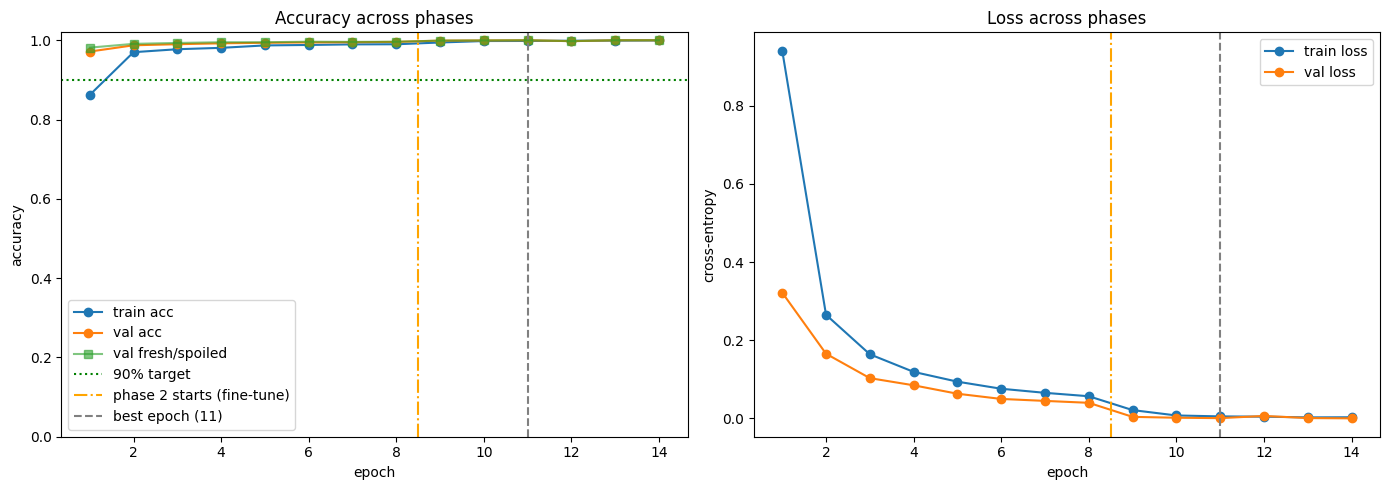

In [8]:
ep_x = range(1, len(history["train_acc"]) + 1)

fig, (axA, axL) = plt.subplots(1, 2, figsize=(14, 5))
axA.plot(ep_x, history["train_acc"], "-o", label="train acc")
axA.plot(ep_x, history["val_acc"],   "-o", label="val acc")
axA.plot(ep_x, history["val_bin"],   "-s", label="val fresh/spoiled", alpha=0.6)
axA.axhline(0.90, ls=":", c="green", label="90% target")
axA.axvline(phase1_epochs + 0.5, ls="-.", c="orange", label="phase 2 starts (fine-tune)")
axA.axvline(best_ep, ls="--", c="gray", label=f"best epoch ({best_ep})")
axA.set_title("Accuracy across phases"); axA.set_xlabel("epoch"); axA.set_ylabel("accuracy")
axA.set_ylim(0, 1.02); axA.legend()

axL.plot(ep_x, history["train_loss"], "-o", label="train loss")
axL.plot(ep_x, history["val_loss"],   "-o", label="val loss")
axL.axvline(phase1_epochs + 0.5, ls="-.", c="orange")
axL.axvline(best_ep, ls="--", c="gray")
axL.set_title("Loss across phases"); axL.set_xlabel("epoch"); axL.set_ylabel("cross-entropy"); axL.legend()
plt.tight_layout(); plt.show()

## 7. Evaluation on validation & test

Best-weights model evaluated on both splits. Test set was never used for selection — honest performance estimate.

In [9]:
val_acc16, val_bin, _, _              = evaluate(model, val_loader)
test_acc16, test_bin, tpreds, ttgts   = evaluate(model, test_loader)

print(f"{'':<14}{'16-class':>12}{'fresh/spoiled':>16}")
print("-"*42)
print(f"{'Validation':<14}{val_acc16:>11.2%}{val_bin:>16.2%}")
print(f"{'Test':<14}{test_acc16:>11.2%}{test_bin:>16.2%}")
print("-"*42)
for name,a16,ab in [("Validation",val_acc16,val_bin),("Test",test_acc16,test_bin)]:
    print(f"{name}: 16-class {'PASS' if a16>=0.90 else 'below'} 90% | "
          f"fresh/spoiled {'PASS' if ab>=0.90 else 'below'} 90%")

                  16-class   fresh/spoiled
------------------------------------------
Validation        100.00%         100.00%
Test               99.91%          99.91%
------------------------------------------
Validation: 16-class PASS 90% | fresh/spoiled PASS 90%
Test: 16-class PASS 90% | fresh/spoiled PASS 90%


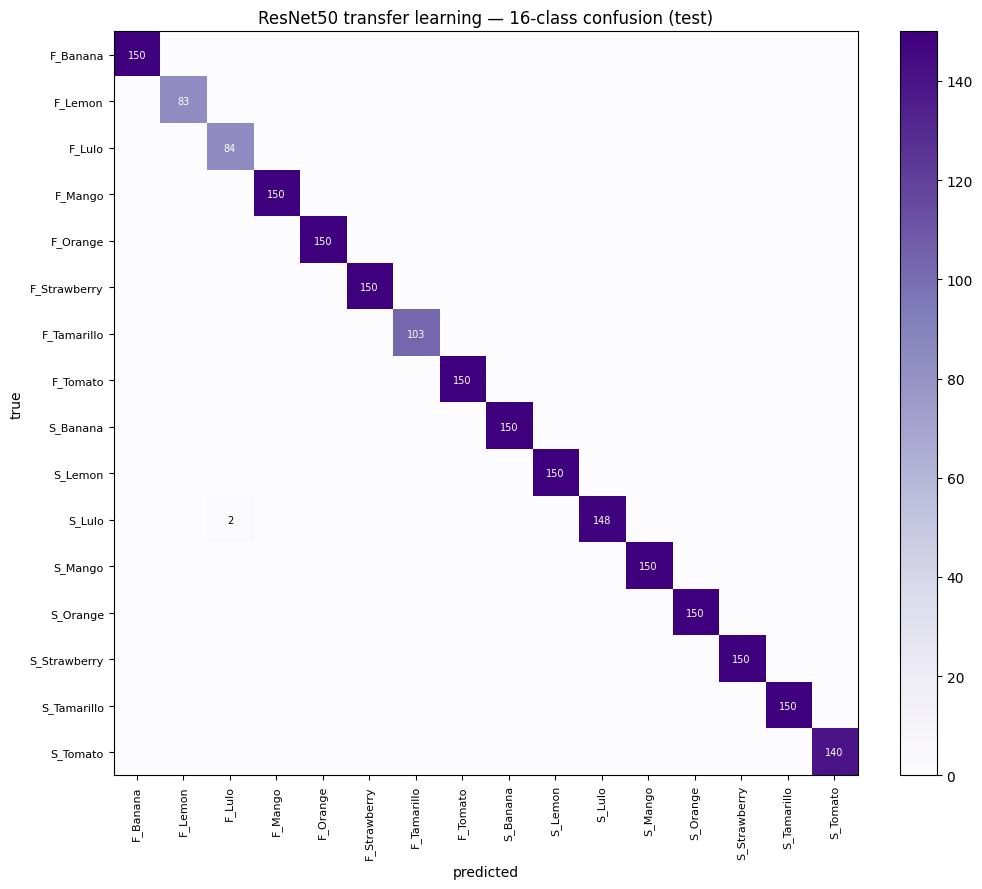

Spoiled predicted FRESH (costly false-pass): 2 / 1190

Per-class report (test):

              precision    recall  f1-score   support

    F_Banana      1.000     1.000     1.000       150
     F_Lemon      1.000     1.000     1.000        83
      F_Lulo      0.977     1.000     0.988        84
     F_Mango      1.000     1.000     1.000       150
    F_Orange      1.000     1.000     1.000       150
F_Strawberry      1.000     1.000     1.000       150
 F_Tamarillo      1.000     1.000     1.000       103
    F_Tomato      1.000     1.000     1.000       150
    S_Banana      1.000     1.000     1.000       150
     S_Lemon      1.000     1.000     1.000       150
      S_Lulo      1.000     0.987     0.993       150
     S_Mango      1.000     1.000     1.000       150
    S_Orange      1.000     1.000     1.000       150
S_Strawberry      1.000     1.000     1.000       150
 S_Tamarillo      1.000     1.000     1.000       150
    S_Tomato      1.000     1.000     1.000       140


In [10]:
# confusion matrix (test) + costly false-pass count
rp, rt = tpreds.numpy(), ttgts.numpy()
cm = confusion_matrix(rt, rp, labels=range(num_classes))
fig, ax = plt.subplots(figsize=(10,9))
im = ax.imshow(cm, cmap="Purples")
ax.set_xticks(range(num_classes)); ax.set_xticklabels(classes, rotation=90, fontsize=8)
ax.set_yticks(range(num_classes)); ax.set_yticklabels(classes, fontsize=8)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("ResNet50 transfer learning — 16-class confusion (test)")
for i in range(num_classes):
    for j in range(num_classes):
        v=cm[i,j]
        if v: ax.text(j,i,v,ha="center",va="center",
                      color="white" if v>cm.max()*0.5 else "black", fontsize=7)
fig.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

fresh_np = is_fresh.cpu().numpy()
cm_bin = confusion_matrix(fresh_np[rt], fresh_np[rp], labels=[0,1])
print(f"Spoiled predicted FRESH (costly false-pass): {cm_bin[0,1]} / {cm_bin[0].sum()}")
print("\nPer-class report (test):\n")
print(classification_report(rt, rp, target_names=classes, digits=3, zero_division=0))

## 8. Save the model

Persist the trained model's **`state_dict`** plus metadata (class names, image size, normalization, val accuracy) to `resnet50_freshharvest.pth`. We reload it into a fresh ResNet50 and re-evaluate to **prove the saved file works**.

In [11]:
SAVE_PATH = "resnet50_freshharvest.pth"
checkpoint = {
    "arch":        "resnet50",
    "state_dict":  model.state_dict(),
    "num_classes": num_classes,
    "classes":     classes,
    "img_size":    IMG_SIZE,
    "norm_mean":   IMAGENET_MEAN,
    "norm_std":    IMAGENET_STD,
    "val_acc":     val_acc16,
    "test_acc":    test_acc16,
}
torch.save(checkpoint, SAVE_PATH)
print(f"Saved -> {SAVE_PATH}  ({os.path.getsize(SAVE_PATH)/1e6:.1f} MB)")

# reload into a fresh model and verify
ckpt = torch.load(SAVE_PATH, map_location=DEVICE, weights_only=False)
reloaded = build_resnet50(ckpt["num_classes"]).to(DEVICE)
reloaded.load_state_dict(ckpt["state_dict"])
r_acc16, r_bin, _, _ = evaluate(reloaded, test_loader)
print(f"Reloaded test acc: 16-class {r_acc16:.2%} | fresh/spoiled {r_bin:.2%}")
print("Reload matches saved model." if abs(r_acc16 - test_acc16) < 1e-6
      else "WARNING: reloaded accuracy differs!")

Saved -> resnet50_freshharvest.pth  (94.5 MB)
Reloaded test acc: 16-class 99.91% | fresh/spoiled 99.91%
Reload matches saved model.


## 9. Conclusions

Using **transfer learning from an ImageNet-pretrained ResNet50** — feature extraction followed by light fine-tuning of `layer4` — reaches the 90 %+ target on the fresh/spoiled task in **only a few epochs per phase**, far fewer than training a CNN from scratch. The pretrained backbone supplies ready-made visual features, so the model converges quickly and cheaply, directly addressing the compute-cost concern.

The trained model is saved to `resnet50_freshharvest.pth` with its class names and preprocessing metadata, and the reload check confirms it is ready to be deployed on the warehouse conveyor-belt system.